<h1 style="text-align: center;">Task-5P</h1>
<h3 style="text-align: right;">Name: Yatharth Deoly</h3>
<h3 style="text-align: right;">StudentId: 224207854</h3>
<h3 style="text-align: right;">EmailId: yatharthdeoly@gmail.com</h3>


## Introduction

In this task, we will be working with Bank Marketing dataset that has been provided by UCI. The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.

Explaining features and targets:

- FEATURES

  - age -> Continuous type
  - job -> type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
  - marital -> marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
  - education -> (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
  - default -> has credit in default?
  - balance -> average yearly balance, units in euros
  - housing -> has housing loan?
  - loan -> has personal loan?
  - contact -> contact communication type (categorical: 'cellular','telephone')
  - day_of_week -> last contact day of the week
  - month -> last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
  - duration -> last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
  - campaign -> number of contacts performed during this campaign and for this client (numeric, includes last contact)
  - pdays -> number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)
  - previous -> number of contacts performed before this campaign and for this client
  - poutcome -> outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')

- TARGET
  - has the client subscribed a term deposit?


Defining imports at the top that will be used by the report.
In this case, having all the imports at the top is more intuitive than having some of them at the top and some of them scattered over the file.


In [24]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np

import warnings

import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# This command tells the IPython environment to draw the plots immediately after the current cell
%matplotlib inline

# Ignore all warnings generated by the Python program
warnings.filterwarnings("ignore")

# Initialize the label encoder
label_encoder = LabelEncoder()

# Creating a list that will be used for keeping all the metrics of different models
train_model_lists = []

# Initialize the randomness in our different models and areassni
random_state = 42

Extracting data into pandas Dataframe from a file.


In [25]:
# Load the dataset with separator as ";"
bank_df = pd.read_csv("bank-full.csv", sep=";")

# Printing random 5 data from our dataframe
bank_df.sample(n=5, random_state=random_state)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3776,40,blue-collar,married,secondary,no,580,yes,no,unknown,16,may,192,1,-1,0,unknown,no
9928,47,services,single,secondary,no,3644,no,no,unknown,9,jun,83,2,-1,0,unknown,no
33409,25,student,single,tertiary,no,538,yes,no,cellular,20,apr,226,1,-1,0,unknown,no
31885,42,management,married,tertiary,no,1773,no,no,cellular,9,apr,311,1,336,1,failure,no
15738,56,management,married,tertiary,no,217,no,yes,cellular,21,jul,121,2,-1,0,unknown,no


In [26]:
# Check for missing values
bank_df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [27]:
# Check for duplicates
bank_df.duplicated().sum()

0

Pre-processing dataset


In [28]:
def create_pipeline(X, y):

    # Create preprocessing steps
    categorical_pipeline_one_hot = Pipeline(
        [
            ("one_hot_encoder", OneHotEncoder()),
            ("scaler", StandardScaler(with_mean=False)),
        ]
    )

    numerical_pipeline = Pipeline([("scaler", StandardScaler())])

    # Identify continuous and categorical features in the training set
    cont_features = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_one_features = X.select_dtypes(include=[object]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat_one_hot", categorical_pipeline_one_hot, cat_one_features),
            ("num", numerical_pipeline, cont_features),
        ],
        remainder="passthrough",
    )

    # Encode the target variable
    y_encoded = label_encoder.fit_transform(y)

    # Split data into training and testing sets
    # Fit the pipeline and transform the data
    X_preprocessed = preprocessor.fit_transform(X)

    # Get feature names after preprocessing
    one_hot_features = list(
        preprocessor.named_transformers_["cat_one_hot"]
        .named_steps["one_hot_encoder"]
        .get_feature_names_out(cat_one_features)
    )
    all_features = one_hot_features + cont_features

    # Convert the preprocessed data back to a DataFrame
    X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_features)

    # Split data into training and testing sets
    return train_test_split(
        X_preprocessed_df,
        y_encoded,
        test_size=0.2,
        random_state=random_state,
        stratify=y_encoded,
    )


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = create_pipeline(
    bank_df.drop("y", axis=1), bank_df["y"]
)

In [29]:
# Generic method for model creation and evaluating model with different metrics
def evaludate_model(model_name, model, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".2f")

    print(
        "Train Accuracy Score:", round(accuracy_score(y_train, y_train_pred) * 100, 2)
    )
    print("Test Accuracy Score:", round(accuracy_score(y_test, y_pred) * 100, 2))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    train_model_lists.append(
        [
            model_name,
            round(accuracy_score(y_train, y_train_pred) * 100, 2),
            round(accuracy_score(y_test, y_pred) * 100, 2),
            round(roc_auc_score(y_test, y_test_prob, multi_class="ovo") * 100, 2),
            round(precision_score(y_test, y_pred, average="weighted") * 100, 2),
            round(recall_score(y_test, y_pred, average="weighted") * 100, 2),
            round(f1_score(y_test, y_pred, average="weighted") * 100, 2),
            model,
        ]
    )

Logistic Regression Model


Train Accuracy Score: 90.2
Test Accuracy Score: 90.15
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



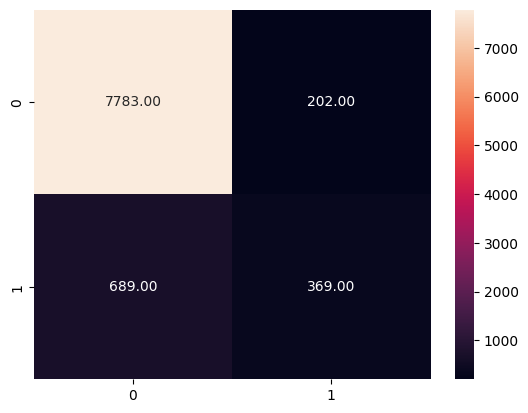

In [30]:
evaludate_model(
    "Logistic_Model",
    LogisticRegression(random_state=random_state, n_jobs=-1),
    X_train,
    X_test,
    y_train,
    y_test,
)

Logistic Regression Model with Hyperparameter Tuning


Best hyperparameters that can be used => {'solver': 'newton-cg', 'penalty': 'l2', 'C': 5}
Train Accuracy Score: 90.2
Test Accuracy Score: 90.14
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



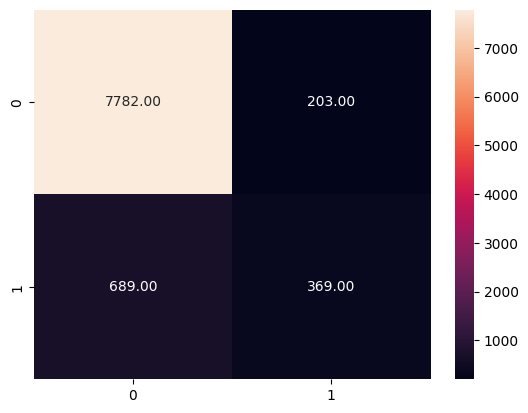

In [31]:
# Define the hyperparameters and the grid
param_grid = {
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"],
    "C": [0.1, 1, 5, 10, 20, 30],
}

random_search = RandomizedSearchCV(
    LogisticRegression(random_state=random_state, n_jobs=-1),
    param_grid,
    cv=5,
    n_jobs=-1,
    random_state=random_state,
)
random_search.fit(X_train, y_train)

print(f"Best hyperparameters that can be used => {random_search.best_params_}")
predicted_model = random_search.best_estimator_

evaludate_model(
    "Logistic_Model_Random",
    random_search.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test,
)

Random Forest Classifier as Ensemble Model


Train Accuracy Score: 100.0
Test Accuracy Score: 90.71
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.67      0.40      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.90      0.91      0.90      9043



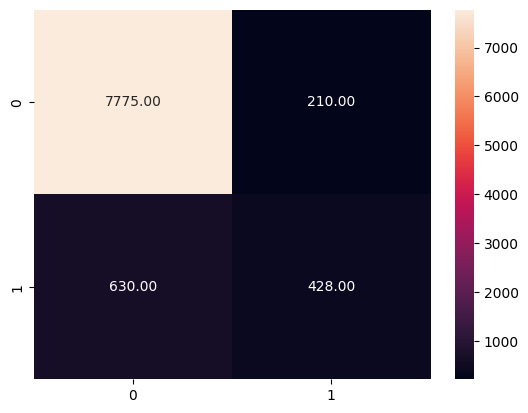

In [32]:
evaludate_model(
    "Random_Forest_Model",
    RandomForestClassifier(random_state=random_state, n_jobs=-1),
    X_train,
    X_test,
    y_train,
    y_test,
)

Gradient Boosting Classifier as Ensemble Model

Train Accuracy Score: 91.18
Test Accuracy Score: 90.55
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.65      0.41      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043



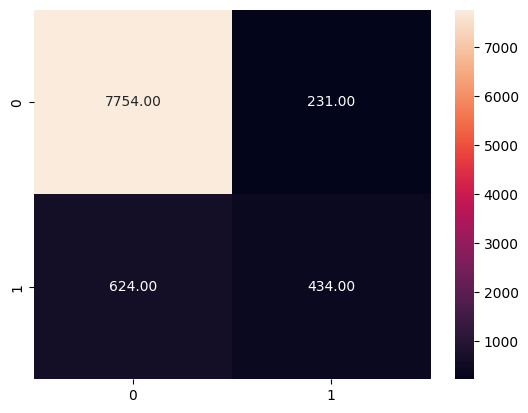

In [33]:
evaludate_model(
    "Gradient_Boosting_Model",
    GradientBoostingClassifier(random_state=random_state),
    X_train,
    X_test,
    y_train,
    y_test,
)

In [34]:
model_df = pd.DataFrame(
    train_model_lists,
    columns=[
        "Model_Name",
        "Train_Accuracy",
        "Test_Accuracy",
        "ROC_AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "Model",
    ],
)

# Prinitng all models metrics in sorted order
model_df.sort_values(by=["Recall", "F1 Score"], ascending=False)

,Model_Name,Train_Accuracy,Test_Accuracy,ROC_AUC,Precision,Recall,F1 Score,Model
2,Random_Forest_Model,100.00,90.71,92.70,89.53,90.71,89.68,"(DecisionTreeClassifier(max_features='sqrt', r..."
3,Gradient_Boosting_Model,91.18,90.55,92.40,89.36,90.55,89.58,([DecisionTreeRegressor(criterion='friedman_ms...
0,Logistic_Model,90.20,90.15,90.55,88.68,90.15,88.82,"LogisticRegression(n_jobs=-1, random_state=42)"
1,Logistic_Model_Random,90.20,90.14,90.55,88.67,90.14,88.81,"LogisticRegression(C=5, n_jobs=-1, random_stat..."


### Analysis
From above metrics, we analyse that `Random_Forest_Model` has best metrics in compare to other models but we won't be using this model for our further analysis and modelling purpose as its `Train_Accuracy` is 100% which means, its over-fitting.
So from the above analysis we will be using `Gradient_Boosting_Model` model.

### Improvement
In target variable, i.e. 'y' have 39922 as 'no' and 5289 as 'yes'. So for this area we can use different techniques like SMOTE for upsampling, k-fold for cross-validation and more other techniques.
Also we can use hyperparamter tunning for other models also with different more models that can be used for analysis.


# Summary

In this report we have learnt about different models i.e. Logistic Regreassion, Ensemble Models i.e. Random Forest Model and Gradient Boosting Model and usage of RandomizedSearchCV. Here we have learnt about different libraries from python, sklearn from loading the file to the modelling and then checking metrics of different models.

# References

- https://archive.ics.uci.edu/dataset/222/bank+marketing
- Different blogs from https://medium.com/ like
  - https://medium.com/analytics-vidhya/understanding-logistic-regression-b3c672deac04
  - https://medium.com/@denizgunay/random-forest-af5bde5d7e1e
  - https://medium.com/@datasciencewizards/understanding-the-gradient-boosting-algorithm-9fe698a352ad
- https://scikit-learn.org/stable/api/sklearn.preprocessing.html
- https://scikit-learn.org/stable/api/sklearn.linear_model.html
- https://scikit-learn.org/stable/api/sklearn.ensemble.html
